In [1]:
import numpy as np
import os
import scipy
import matplotlib.pyplot as plt
import glob as glob
from scipy.io import loadmat
from path import Path
%run Functions_Beh.ipynb

In [2]:
# Constants
mouse = '477116'
date = '20251118'
session = 'retrieval'
path = '/vol/battaglialab/imaging1/Veronique/2p_behavior_datasets/OFL/' + mouse + '/preprocessed/'
data = glob.glob(os.path.join(path,'*_decoded.mat'))[0]
struct = loadmat(data)

In [3]:
# Output folder
output_path = Path("/vol/battaglialab/imaging1/Veronique/2p_behavior_datasets/OFL/") / mouse / "Output" / date / session

In [4]:
# Separate data in analog, digital, states
digital_in = struct['digitalIn']
digital_out = struct['digitalOut']
states = struct['longVar']
long = struct['packetNums']
analog = struct['analog']
num_packet = len(long[0])
time = num_packet/1000

In [5]:
len(digital_in[:,1])

2139534

In [6]:
# Define all channels
nature = digital_in[:,11] #nature environment
halloween = digital_in[:,12] #halloween environment
rz = digital_in[:,9] #reward zone
reward = digital_out[:,0] #reward
licks = analog[:,1] #licks
breathing = analog[:,2] #should check this, I might have changed this
shock_exp = digital_out[:,6] #start shock experiment
shock_grid = digital_out[:,7] #corresponding shock grid

Plot all of these together
The default figure size is 16cm wide and 12.19cm in height. Using figsize, we can change the size. The first number is the width, second number is the height.

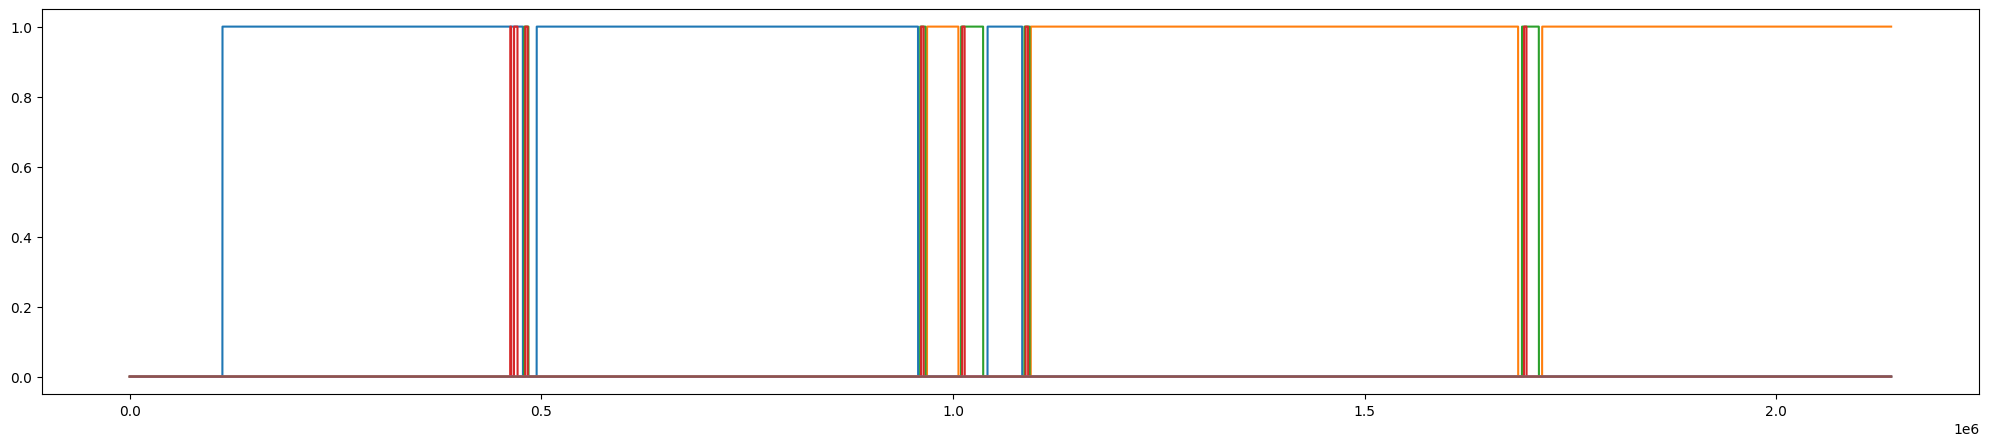

In [7]:
# Quick check
plt.figure(figsize=(25,5))
plt.plot(nature) #blue
plt.plot(halloween) #yellow
plt.plot(rz) #green
plt.plot(reward) #red
plt.plot(shock_exp) #purple
plt.plot(shock_grid)#brown

### Define time stamps start/stop events
###### np.argwhere()
Function is used to find the indices of array elements that are non-zero, grouped by element.

###### flatten()
flatten is taking any multi-dimensional array and lays it out in a single row.
Example:
[[1,2],
[3,4]]
turns into [1,2,3,4].

###### np.diff()
Looks at consecutive values and computes the difference between each entry and the next one.
Input: [a,b,c,d]
Output: [b-a, c-b, d-c]
So it gives ghow much the number has changed.

###### > 2
Now we have a list of differences between conescutive values. The expression > 2 means "which are greater than 2"


In [8]:
# nature
n_time = np.argwhere(nature==1).T
n_inter = np.argwhere(np.diff(n_time.flatten())>2)
n_start = n_time[0,np.vstack((0,n_inter+1)).flatten()]
n_end = n_time[0,np.vstack((n_inter,n_time.shape[1]-1)).flatten()]

In [9]:
# halloween
h_time = np.argwhere(halloween==1).T
h_inter = np.argwhere(np.diff(h_time.flatten())>2)
h_start = h_time[0,np.vstack((0,h_inter+1)).flatten()]
h_end = h_time[0,np.vstack((h_inter,h_time.shape[1]-1)).flatten()]

In [10]:
# Reward Zone
rz_time = np.argwhere(rz==1).T
rz_inter = np.argwhere(np.diff(rz_time.flatten())>2)
rz_start = rz_time[0,np.vstack((0,rz_inter+1)).flatten()]
rz_end = rz_time[0,np.vstack((rz_inter,rz_time.shape[1]-1)).flatten()]

In [11]:
# Reward
rw_time = np.argwhere(reward==1).T
rw_inter = np.argwhere(np.diff(rw_time.flatten())>2)
rw_start = rw_time[0,np.vstack((0,rw_inter+1)).flatten()]
rw_end = rw_time[0,np.vstack((rw_inter,rw_time.shape[1]-1)).flatten()]

In [12]:
# Shock experiment (grid and experiment)
s_time = np.argwhere(shock_exp==1).T
g_time = np.argwhere(shock_grid==1).T

if s_time.size > 1:
    s_inter = np.argwhere(np.diff(s_time.flatten())>2)
    g_inter = np.argwhere(np.diff(g_time.flatten())>2)

    s_start = s_time[0,np.vstack((0,s_inter+1)).flatten()]
    g_start = g_time[0,np.vstack((0,g_inter+1)).flatten()]

    s_end = s_time[0,np.vstack((s_inter,s_time.shape[1]-1)).flatten()]
    g_end = g_time[0,np.vstack((g_inter,g_time.shape[1]-1)).flatten()]
else:
    print("no shocks")

no shocks


In [13]:
all_trials_start = np.concatenate((n_start,h_start))
all_trials_end = np.concatenate([n_end,h_end])

number_trials = len(np.concatenate((n_start,h_start)))

In [14]:
all_trials_end

array([ 477428,  957453, 1083926, 1006478, 1686372, 2139533])

### Single trial distance

In [15]:
distance = states[:,1]

# Only uncommand this one for first session pilot animal
distance[109696:110207] = 0


In [21]:
distance

array([    0,     0,     0, ..., 12320, 12320, 12320],
      shape=(2139534,), dtype=uint32)

In [16]:
distance[all_trials_start[0]]

np.uint32(50)

In [17]:
trials = []

for m in range(len(all_trials_start)):
    start = distance[all_trials_start[m]]
    single_trial = distance[all_trials_start[m]:all_trials_end[m]]
    corrected_single_trial = np.array([d - start for d in single_trial])

    trials.append(corrected_single_trial)

    trials_running_beh = np.concatenate(trials)




In [20]:
trials

[array([   0,    0,    0, ..., 1498, 1498, 1498],
       shape=(364941,), dtype=uint32),
 array([   0,    0,    0, ..., 1498, 1498, 1498],
       shape=(463268,), dtype=uint32),
 array([   0,    0,    0, ..., 1498, 1498, 1498],
       shape=(42068,), dtype=uint32),
 array([   0,    1,    1, ..., 1500, 1500, 1500],
       shape=(38132,), dtype=uint32),
 array([   0,    0,    0, ..., 1502, 1502, 1502],
       shape=(591982,), dtype=uint32),
 array([   0,    1,    1, ..., 1294, 1294, 1294],
       shape=(423989,), dtype=uint32)]

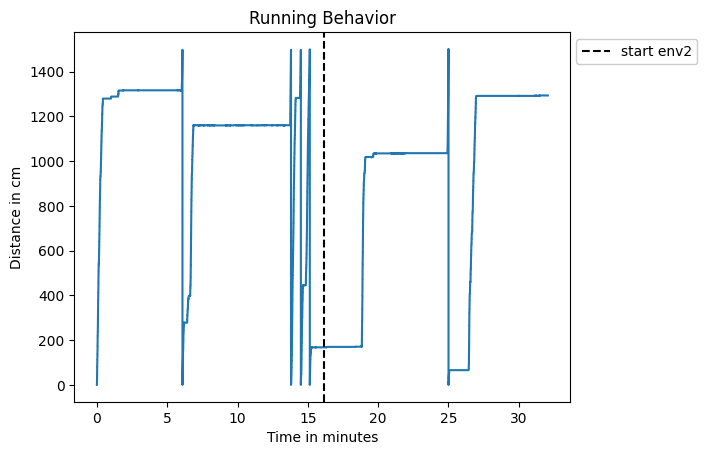

In [18]:
fig, ax = plt.subplots()

x = np.arange(len(trials_running_beh))
x_minutes = x / 60000

ax.plot(x_minutes, trials_running_beh)
ax.axvline(x=h_start[0] / 60000, color='black', ls='--', label='start env2')

ax.set_title("Running Behavior")
ax.set_ylabel("Distance in cm")
ax.set_xlabel("Time in minutes")
ax.legend(bbox_to_anchor=(1.27, 1), loc='upper right',framealpha=1)

fig.savefig(
    os.path.join(output_path, "running_behavior.eps"),
    format="eps",
    bbox_inches="tight"
)


### Freezing first lap/all laps

In [18]:
trials_diff = []

for x in range(len(trials)):
    diff = np.diff(trials[x].astype(np.int64))

    trials_diff.append(diff)

In [19]:
# Compute the distance (m) ran per 1000ms
window_size = 1000
mov_per_sec = []

for trial in range(len(trials_diff)):
    trial_result = []
    for dist in range(0, len(trials_diff[trial]),window_size):
        temp_var = np.sum(trials_diff[trial][dist:dist+window_size])
        trial_result.append(temp_var/1000)
    mov_per_sec.append(trial_result)


In [20]:
# Calculate how often the animal freezes
bouts = []

for trial in range(len(mov_per_sec)):
    count = 0
    trial_bouts = []
    for sec in range(len(mov_per_sec[trial])):
        if mov_per_sec[trial][sec] == 0:
            count += 1
        else:
            trial_bouts.append(count)
            count = 0
    # catch freezing at the very end of the trial
    if count > 0:
        trial_bouts.append(count)
    bouts.append(trial_bouts)


In [21]:
# Turn this in percentage of freezing per environment
total_freezing = sum(len(trials) for trials in bouts)
perc_freezing_trial = [len(frz) / total_freezing * 100 for frz in bouts]

In [41]:
first_trials = len(n_start)

In [34]:
n_freezing = perc_freezing_trial[:first_trials]
h_freezing = perc_freezing_trial[first_trials:]
combined = [n_freezing, h_freezing]
first_trials = [n_freezing[0], h_freezing[0]]

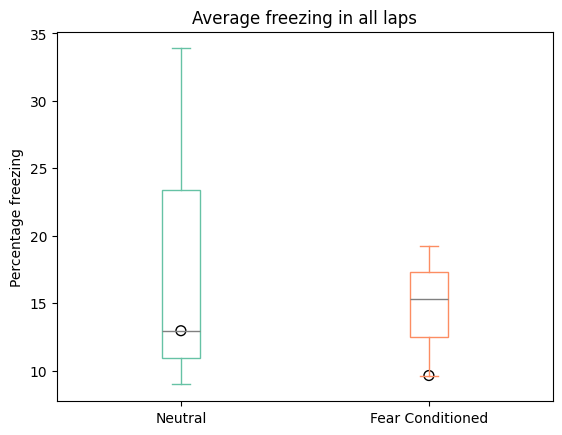

In [81]:
import seaborn as sns
fig, ax = plt.subplots()
bp = ax.boxplot(combined, patch_artist=True)
colors = sns.color_palette("Set2", n_colors=2)  # 6 colors from Set2

for i, color in enumerate(colors):
    # Box outline
    bp['boxes'][i].set(edgecolor=color, facecolor='none', linewidth=1)

    # Median line
    bp['medians'][i].set(color="gray", linewidth=1)

    # Whiskers (lower and upper)
    bp['whiskers'][2*i].set(color=color, linewidth=1)
    bp['whiskers'][2*i + 1].set(color=color, linewidth=1)

    # Caps (lower and upper)
    bp['caps'][2*i].set(color=color, linewidth=1)
    bp['caps'][2*i + 1].set(color=color, linewidth=1)

ax.scatter(1, n_freezing[0], edgecolor='black', facecolor='none', s=50)
ax.scatter(2, h_freezing[0], edgecolor='black', facecolor='none', s=50)
ax.set_ylabel("Percentage freezing")
ax.set_xticklabels(['Neutral', 'Fear Conditioned'])
ax.set_title("Average freezing in all laps")

fig.savefig(
    os.path.join(output_path, "freezing.eps"),
    format="eps",
    bbox_inches="tight"
)


### Time it takes to complete a lap

In [36]:
trial_duration = []
for trial in range(len(trials)):
    duration = len(trials[trial]) / 1000
    trial_duration.append(duration)


In [45]:
n_duration = trial_duration[:first_trials]
h_duration = trial_duration[first_trials:]
combined_duration = [n_duration,h_duration]

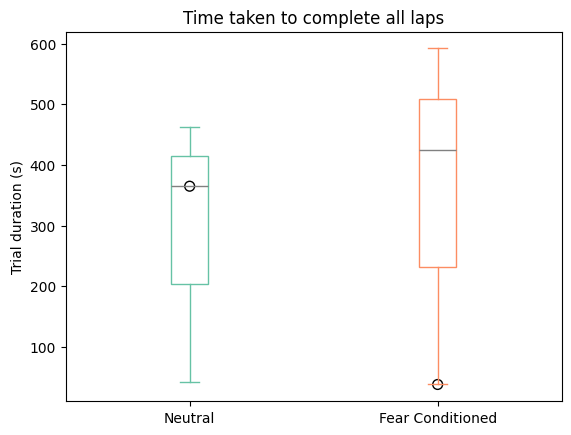

In [82]:
fig, ax = plt.subplots()
bp = ax.boxplot(combined_duration, patch_artist=True)
colors = sns.color_palette("Set2", n_colors=2)  # 6 colors from Set2

for i, color in enumerate(colors):
    # Box outline
    bp['boxes'][i].set(edgecolor=color, facecolor='none', linewidth=1)

    # Median line
    bp['medians'][i].set(color="gray", linewidth=1)

    # Whiskers (lower and upper)
    bp['whiskers'][2*i].set(color=color, linewidth=1)
    bp['whiskers'][2*i + 1].set(color=color, linewidth=1)

    # Caps (lower and upper)
    bp['caps'][2*i].set(color=color, linewidth=1)
    bp['caps'][2*i + 1].set(color=color, linewidth=1)

ax.scatter(1, n_duration[0], edgecolor='black', facecolor='none', s=50)
ax.scatter(2, h_duration[0], edgecolor='black', facecolor='none', s=50)
ax.set_ylabel("Trial duration (s)")
ax.set_xticklabels(['Neutral', 'Fear Conditioned'])
ax.set_title("Time taken to complete all laps")
fig.savefig(
    os.path.join(output_path, "lapduration.eps"),
    format="eps",
    bbox_inches="tight"
)